In [1]:
import glob
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from scipy.stats import kstest, mannwhitneyu, ranksums, ttest_ind
from statsmodels.stats.multitest import fdrcorrection, multipletests

%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

from sklearn.impute import SimpleImputer

In [41]:
sim_result = pd.read_csv(
    './Fig.S3.value.csv',
    index_col=0) /100
sim_result_melt = sim_result.T.melt()*100
sim_result_melt.columns = ['Actual(%)', 'Predicted(%)']
sim_result_melt =sim_result_melt.astype({'Predicted(%)':int,'Actual(%)':int})

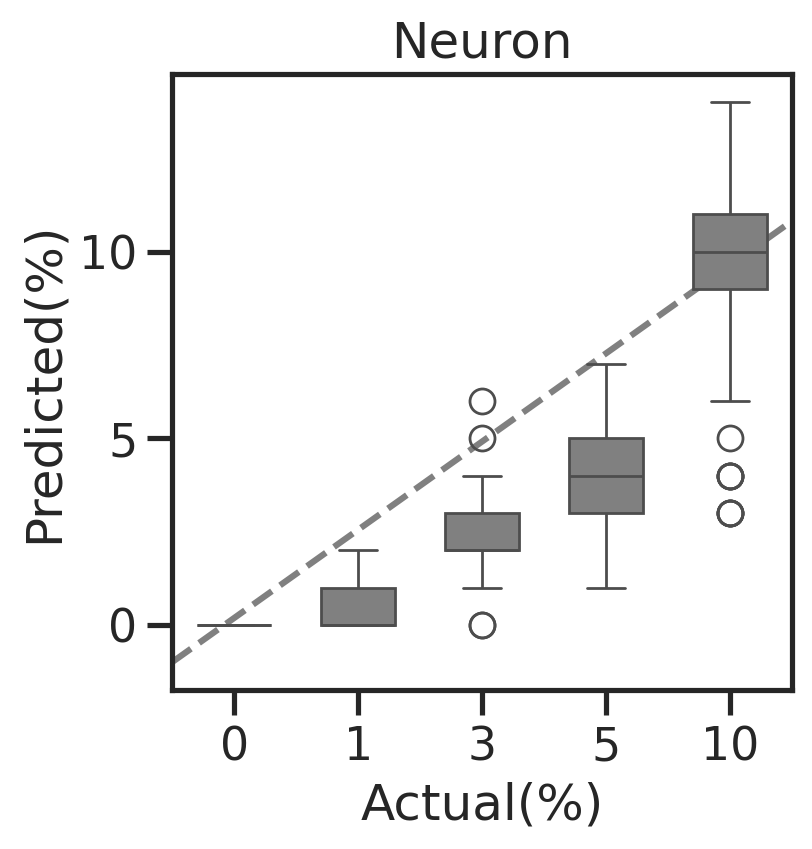

In [42]:
f, ax = plt.subplots(figsize=(4, 4))
sns.set_theme(context='talk', style='ticks')
plt.plot([-0.5, 5], [-1, 12], '--', color='grey')
sns.boxplot(sim_result_melt,
            x='Actual(%)',
            y='Predicted(%)',
            ax=ax,
            showmeans=False,
            width=0.6,
            dodge=True,
            showfliers=True,
            color='grey')
#ax.legend(bbox_to_anchor=(1, 0.6), frameon=False)

ax.set(title='Neuron')
#ax.tick_params(axis='x', rotation=30)
f.figure.savefig(
    './Fig.S3.png',
    bbox_inches='tight',
    dpi=600)